# Video Violence Detection: Multi-Architecture Comparison
**Architectures:** CNN-LSTM | VideoMAE | YOLO+LSTM  
**Hardware:** 2x Tesla T4 (DDP via Accelerate)  
**Dataset:** RLVS + RWF-2000 (Deduplicated & Cleaned)

## 1. Environment Setup & Configuration
We initialize the environment, install necessary packages (`accelerate`, `transformers`, `ultralytics`), and define the global configuration.
**Key Configs:**
- `num_frames`: 16 (Standard for R(2+1)D / VideoMAE)
- `img_size`: 224x224
- `early_stopping`: 3 epochs patience

In [1]:
!pip install -q accelerate transformers ultralytics timm av

import os
import cv2
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms as T, models
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, roc_curve, auc
from tqdm.auto import tqdm
from pathlib import Path
from hashlib import md5
from accelerate import Accelerator
from transformers import VideoMAEForVideoClassification, VideoMAEImageProcessor
from ultralytics import YOLO
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')

CFG = {
    'seed': 42,
    'num_frames': 16,
    'img_size': 224,
    'batch_size': 8,
    'epochs': 10,
    'early_stopping': 3,  # Patience for early stopping
    'lr': 1e-4,
    'weight_decay': 1e-4,
    'num_workers': 4,
    'max_dur_frames': 240,
    'videomae_frames': 16
}

torch.manual_seed(CFG['seed'])
np.random.seed(CFG['seed'])

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 19.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.2/41.2 MB 44.2 MB/s eta 0:00:00


2026-01-28 01:26:06.817593: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1769563567.066610      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1769563567.138412      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1769563567.718423      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1769563567.718468      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1769563567.718472      24 computation_placer.cc:177] computation placer alr

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


## 2. Data Preprocessing (Leakage Fix)
We apply the critical **EDA findings** from the previous phase:
1. **Deduplication:** Hashing files to remove duplicates (prevents train/val leakage).
2. **Stratified Split:** Ensuring balanced classes in Train/Val sets (80/20 split).
3. **Data Source:** Merging `RLVS` and `RWF-2000` datasets.

In [ ]:
def get_file_hash(path):
    with open(path, 'rb') as f:
        return md5(f.read(1024 * 1024)).hexdigest()

def prepare_data(root_dir):
    data = []
    root = Path(root_dir)
    
    for dataset in ['Violence Fight Detection dataset/RLVS', 'RWF-2000']:
        ds_path = root / dataset
        for split in ['train', 'val']:
            for label in ['Fight', 'NonFight']:
                folder = ds_path / split / label
                if not folder.exists(): continue
                for vid in folder.glob('*.mp4'):
                    data.append({
                        'path': str(vid),
                        'label': 1 if label == 'Fight' else 0,
                        'split': split,
                        'dataset': dataset.split('/')[0]
                    })
    
    df = pd.DataFrame(data)
    tqdm.pandas(desc="Hashing")
    df['file_hash'] = df['path'].progress_apply(get_file_hash)
    
    init_len = len(df)
    df = df.drop_duplicates(subset=['file_hash'], keep='first').reset_index(drop=True)
    print(f"Dropped {init_len - len(df)} duplicates | Remaining: {len(df)}")
    
    train_df, val_df = train_test_split(
        df, test_size=0.2, stratify=df['label'], random_state=CFG['seed']
    )
    return train_df.reset_index(drop=True), val_df.reset_index(drop=True)

DATA_ROOT = '/kaggle/input/video-violence-detection-dataset'
train_df, val_df = prepare_data(DATA_ROOT)
print(f"Train: {len(train_df)} | Val: {len(val_df)} | Balance: {train_df['label'].mean():.2%}")

Hashing:   0%|          | 0/1951 [00:00<?, ?it/s]

Dropped 14 duplicates | Remaining: 1937
Train: 1549 | Val: 388 | Balance: 51.26%


## 3. Base Dataset & Video Utilities
A robust `Dataset` class that handles:
- **Frame Extraction:** Uniformly samples `num_frames` from video.
- **Resizing:** Transforms inputs to `(224, 224)`.
- **Handling Corruptions:** Pads short videos with black frames if necessary.

In [ ]:
def extract_frames(path, num_frames, img_size, max_frames=None):
    cap = cv2.VideoCapture(path)
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    if max_frames and total > max_frames:
        total = max_frames
    
    indices = np.linspace(0, max(total-1, 0), num_frames, dtype=int) if total > 0 else np.zeros(num_frames, dtype=int)
    frames = []
    
    for i in indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, i)
        ret, frame = cap.read()
        if ret:
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            frame = cv2.resize(frame, (img_size, img_size))
            frames.append(frame)
        else:
            frames.append(np.zeros((img_size, img_size, 3), dtype=np.uint8))
    cap.release()
    
    while len(frames) < num_frames:
        frames.append(np.zeros((img_size, img_size, 3), dtype=np.uint8))
    return np.array(frames[:num_frames])

class BaseVideoDataset(Dataset):
    def __init__(self, df, num_frames=16, img_size=224, transform=None):
        self.paths = df['path'].values
        self.labels = df['label'].values
        self.num_frames = num_frames
        self.img_size = img_size
        self.transform = transform
    
    def __len__(self):
        return len(self.paths)
    
    def __getitem__(self, idx):
        frames = extract_frames(self.paths[idx], self.num_frames, self.img_size, CFG['max_dur_frames'])
        label = torch.tensor(self.labels[idx], dtype=torch.float)
        
        if self.transform:
            frames = np.stack([self.transform(f) for f in frames])
        return frames, label

## 4. Architecture 1: CNN-LSTM
**Hybrid Approach:**
- **Backbone:** frozen `ResNet50` (ImageNet weights) extracts spatial features per frame.
- **Temporal Head:** Bidirectional `LSTM` (2 layers) aggregates temporal dynamics.
- **Goal:** Effective baseline combining spatial power with sequence modeling.

In [ ]:
class CNNLSTMDataset(BaseVideoDataset):
    def __init__(self, df):
        transform = T.Compose([
            T.ToTensor(),
            T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
        ])
        super().__init__(df, num_frames=CFG['num_frames'], img_size=CFG['img_size'], transform=transform)
    
    def __getitem__(self, idx):
        frames = extract_frames(self.paths[idx], self.num_frames, self.img_size, CFG['max_dur_frames'])
        frames = torch.stack([self.transform(f) for f in frames])
        return frames, torch.tensor(self.labels[idx], dtype=torch.float)

class CNNLSTM(nn.Module):
    def __init__(self, hidden_size=512, num_layers=2, dropout=0.5):
        super().__init__()
        resnet = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
        self.cnn = nn.Sequential(*list(resnet.children())[:-1])
        for param in self.cnn.parameters():
            param.requires_grad = False
        
        self.lstm = nn.LSTM(
            input_size=2048,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if num_layers > 1 else 0
        )
        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(hidden_size * 2, 1)
        )
    
    def forward(self, x):
        B, T, C, H, W = x.shape
        x = x.view(B * T, C, H, W)
        with torch.no_grad():
            features = self.cnn(x).squeeze(-1).squeeze(-1)
        features = features.view(B, T, -1)
        lstm_out, _ = self.lstm(features)
        return self.classifier(lstm_out[:, -1, :])

## 5. Architecture 2: VideoMAE (Transformer)
**SOTA Vision Transformer:**
- **Model:** `MCG-NJU/videomae-base-finetuned-kinetics`.
- **Method:** Masked Autoencoder tailored for video.
- **Fine-tuning:** Freezing backbone, unfreezing last 2 encoder layers for domain adaptation.
- **Input:** Pixel values processed by `VideoMAEImageProcessor`.

In [ ]:
class VideoMAEDataset(Dataset):
    def __init__(self, df):
        self.paths = df['path'].values
        self.labels = df['label'].values
        self.processor = VideoMAEImageProcessor.from_pretrained("MCG-NJU/videomae-base-finetuned-kinetics")
    
    def __len__(self):
        return len(self.paths)
    
    def __getitem__(self, idx):
        frames = extract_frames(self.paths[idx], CFG['videomae_frames'], 224, CFG['max_dur_frames'])
        frames_list = [f for f in frames]
        inputs = self.processor(frames_list, return_tensors="pt")
        pixel_values = inputs['pixel_values'].squeeze(0)
        return pixel_values, torch.tensor(self.labels[idx], dtype=torch.long)

class VideoMAEClassifier(nn.Module):
    def __init__(self, num_classes=2, dropout=0.5):
        super().__init__()
        self.videomae = VideoMAEForVideoClassification.from_pretrained(
            "MCG-NJU/videomae-base-finetuned-kinetics",
            num_labels=num_classes,
            ignore_mismatched_sizes=True
        )
        for param in self.videomae.videomae.parameters():
            param.requires_grad = False
        for param in self.videomae.videomae.encoder.layer[-2:].parameters():
            param.requires_grad = True
    
    def forward(self, pixel_values):
        outputs = self.videomae(pixel_values=pixel_values)
        return outputs.logits

## 6. Architecture 3: YOLO + LSTM (Object-Centric)
**Lightweight / Interpretability Focused:**
- **Extractor:** `YOLOv8n` detects 'person' objects.
- **Features:** Bounding box stats (Center X/Y, Width, Height, Area, Count, Spread).
- **Sequence:** Simple coordinate vectors fed into LSTM.
- **Efficiency:** Caches extracted features to disk (`.npy`) for ultra-fast training.

In [ ]:
class YOLOLSTMDataset(Dataset):
    def __init__(self, df, cache_dir='/kaggle/working/yolo_cache'):
        self.paths = df['path'].values
        self.labels = df['label'].values
        self.yolo = YOLO('yolov8n.pt')
        self.cache_dir = Path(cache_dir)
        self.cache_dir.mkdir(exist_ok=True)
    
    def __len__(self):
        return len(self.paths)
    
    def _extract_bbox_features(self, path):
        cache_file = self.cache_dir / f"{md5(path.encode()).hexdigest()}.npy"
        if cache_file.exists():
            return np.load(cache_file)
        
        frames = extract_frames(path, CFG['num_frames'], 640, CFG['max_dur_frames'])
        features = []
        
        for frame in frames:
            results = self.yolo(frame, verbose=False, classes=[0])[0]
            if len(results.boxes) > 0:
                boxes = results.boxes.xywhn.cpu().numpy()
                cx, cy = boxes[:, 0].mean(), boxes[:, 1].mean()
                w, h = boxes[:, 2].mean(), boxes[:, 3].mean()
                area = (boxes[:, 2] * boxes[:, 3]).sum()
                count = len(boxes)
                features.append([cx, cy, w, h, area, count, boxes[:, 0].std(), boxes[:, 1].std()])
            else:
                features.append([0.5, 0.5, 0, 0, 0, 0, 0, 0])
        
        features = np.array(features, dtype=np.float32)
        np.save(cache_file, features)
        return features
    
    def __getitem__(self, idx):
        features = self._extract_bbox_features(self.paths[idx])
        return torch.tensor(features, dtype=torch.float), torch.tensor(self.labels[idx], dtype=torch.float)

class YOLOLSTM(nn.Module):
    def __init__(self, input_size=8, hidden_size=128, num_layers=2, dropout=0.3):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if num_layers > 1 else 0
        )
        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(hidden_size * 2, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 1)
        )
    
    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        return self.classifier(lstm_out[:, -1, :])

## 7. Unified Training Engine
A reusable `TrainingEngine` class to standardise the loop across different models.
- **Accelerator:** Handles DDP (Distributed Data Parallel) on 2x T4 GPUs.
- **Mixed Precision:** FP16 for speed.
- **Early Stopping:** Monitors validation loss with customizable patience.
- **Model Checkpointing:** Saves best weights based on Val Accuracy.

In [7]:
class TrainingEngine:
    def __init__(self, model_name, model, train_loader, val_loader, criterion, is_multiclass=False):
        self.accelerator = Accelerator(mixed_precision="fp16")
        self.model_name = model_name
        self.is_multiclass = is_multiclass
        self.criterion = criterion
        
        self.optimizer = torch.optim.AdamW(
            filter(lambda p: p.requires_grad, model.parameters()),
            lr=CFG['lr'], weight_decay=CFG['weight_decay']
        )
        
        self.model, self.optimizer, self.train_loader, self.val_loader = self.accelerator.prepare(
            model, self.optimizer, train_loader, val_loader
        )
        
        self.history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
        self.best_val_acc = 0.0
    
    def train_epoch(self):
        self.model.train()
        total_loss, correct, total = 0, 0, 0
        
        for inputs, labels in tqdm(self.train_loader, desc=f"{self.model_name} Train", leave=False):
            self.optimizer.zero_grad()
            outputs = self.model(inputs)
            
            if self.is_multiclass:
                loss = self.criterion(outputs, labels)
                preds = outputs.argmax(dim=1)
            else:
                outputs = outputs.squeeze(-1)
                loss = self.criterion(outputs, labels)
                preds = (torch.sigmoid(outputs) > 0.5).long()
            
            self.accelerator.backward(loss)
            self.optimizer.step()
            
            total_loss += loss.item()
            correct += (preds == labels.long()).sum().item()
            total += labels.size(0)
        
        return total_loss / len(self.train_loader), correct / total
    
    @torch.no_grad()
    def validate(self):
        self.model.eval()
        total_loss, all_preds, all_labels, all_probs = 0, [], [], []
        
        for inputs, labels in tqdm(self.val_loader, desc=f"{self.model_name} Val", leave=False):
            outputs = self.model(inputs)
            
            if self.is_multiclass:
                loss = self.criterion(outputs, labels)
                probs = F.softmax(outputs, dim=1)[:, 1]
                preds = outputs.argmax(dim=1)
            else:
                outputs = outputs.squeeze(-1)
                loss = self.criterion(outputs, labels)
                probs = torch.sigmoid(outputs)
                preds = (probs > 0.5).long()
            
            total_loss += loss.item()
            all_preds.extend(self.accelerator.gather(preds).cpu().numpy())
            all_labels.extend(self.accelerator.gather(labels).cpu().numpy())
            all_probs.extend(self.accelerator.gather(probs).cpu().numpy())
        
        return total_loss / len(self.val_loader), all_preds, all_labels, all_probs
    
    def fit(self, epochs=CFG['epochs'], patience=CFG['early_stopping']):
        patience_counter = 0
        best_loss = float('inf')
        
        for epoch in range(epochs):
            train_loss, train_acc = self.train_epoch()
            val_loss, val_preds, val_labels, val_probs = self.validate()
            val_acc = accuracy_score(val_labels, val_preds)
            
            self.history['train_loss'].append(train_loss)
            self.history['val_loss'].append(val_loss)
            self.history['train_acc'].append(train_acc)
            self.history['val_acc'].append(val_acc)
            
            if self.accelerator.is_main_process:
                print(f"[{self.model_name}] Epoch {epoch+1}/{epochs} | "
                      f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
                      f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")
                
                if val_acc > self.best_val_acc:
                    self.best_val_acc = val_acc
                    unwrapped = self.accelerator.unwrap_model(self.model)
                    torch.save(unwrapped.state_dict(), f"best_{self.model_name.lower().replace('-', '_')}.pth")
            
            # Early Stopping (Val Loss)
            if val_loss < best_loss:
                best_loss = val_loss
                patience_counter = 0
            else:
                patience_counter += 1
                if patience_counter >= patience:
                    print(f"[{self.model_name}] Early stopping triggered at epoch {epoch+1}")
                    break
        
        return self.history, (val_preds, val_labels, val_probs)

## 8. Training Execution
We train all 3 models sequentially using the `TrainingEngine`.
- **CNN-LSTM:** Standard 16-frame training.
- **VideoMAE:** Uses reduced batch size (memory intensive).
- **YOLO-LSTM:** Extracts features first (CPU heavy), then trains LSTM (very light).

In [ ]:
results = {}

# --- CNN-LSTM ---
print("\nTraining CNN-LSTM")
print("=" * 50)
cnn_lstm_train = CNNLSTMDataset(train_df)
cnn_lstm_val = CNNLSTMDataset(val_df)
cnn_lstm_train_loader = DataLoader(cnn_lstm_train, batch_size=CFG['batch_size'], shuffle=True, num_workers=CFG['num_workers'], pin_memory=True)
cnn_lstm_val_loader = DataLoader(cnn_lstm_val, batch_size=CFG['batch_size'], shuffle=False, num_workers=CFG['num_workers'], pin_memory=True)

cnn_lstm_model = CNNLSTM()
cnn_lstm_engine = TrainingEngine('CNN-LSTM', cnn_lstm_model, cnn_lstm_train_loader, cnn_lstm_val_loader, nn.BCEWithLogitsLoss())
results['CNN-LSTM'] = cnn_lstm_engine.fit()

# --- VideoMAE ---
print("\nTraining VideoMAE")
print("=" * 50)
videomae_train = VideoMAEDataset(train_df)
videomae_val = VideoMAEDataset(val_df)
videomae_train_loader = DataLoader(videomae_train, batch_size=CFG['batch_size']//2, shuffle=True, num_workers=CFG['num_workers'], pin_memory=True)
videomae_val_loader = DataLoader(videomae_val, batch_size=CFG['batch_size']//2, shuffle=False, num_workers=CFG['num_workers'], pin_memory=True)

videomae_model = VideoMAEClassifier()
videomae_engine = TrainingEngine('VideoMAE', videomae_model, videomae_train_loader, videomae_val_loader, nn.CrossEntropyLoss(), is_multiclass=True)
results['VideoMAE'] = videomae_engine.fit()

# --- YOLO-LSTM ---
print("\nTraining YOLO-LSTM")
print("=" * 50)
yolo_lstm_train = YOLOLSTMDataset(train_df)
yolo_lstm_val = YOLOLSTMDataset(val_df)
yolo_lstm_train_loader = DataLoader(yolo_lstm_train, batch_size=CFG['batch_size']*2, shuffle=True, num_workers=0, pin_memory=True)
yolo_lstm_val_loader = DataLoader(yolo_lstm_val, batch_size=CFG['batch_size']*2, shuffle=False, num_workers=0, pin_memory=True)

yolo_lstm_model = YOLOLSTM()
yolo_lstm_engine = TrainingEngine('YOLO-LSTM', yolo_lstm_model, yolo_lstm_train_loader, yolo_lstm_val_loader, nn.BCEWithLogitsLoss())
results['YOLO-LSTM'] = yolo_lstm_engine.fit()

print("\nAll training complete!")


Training CNN-LSTM
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 180MB/s]


CNN-LSTM Train:   0%|          | 0/194 [00:00<?, ?it/s]

CNN-LSTM Val:   0%|          | 0/49 [00:00<?, ?it/s]

[h264 @ 0x413c6fc0] mb_type 104 in P slice too large at 98 31
[h264 @ 0x413c6fc0] error while decoding MB 98 31
[h264 @ 0x413c6fc0] mb_type 104 in P slice too large at 98 31
[h264 @ 0x413c6fc0] error while decoding MB 98 31
[h264 @ 0x413c6fc0] mb_type 104 in P slice too large at 98 31
[h264 @ 0x413c6fc0] error while decoding MB 98 31


...

YOLO-LSTM Val:   0%|          | 0/25 [00:00<?, ?it/s]

[YOLO-LSTM] Epoch 9/10 | Train Loss: 0.6263 Acc: 0.6385 | Val Loss: 0.6159 Acc: 0.6418


YOLO-LSTM Train:   0%|          | 0/97 [00:00<?, ?it/s]

YOLO-LSTM Val:   0%|          | 0/25 [00:00<?, ?it/s]

[YOLO-LSTM] Epoch 10/10 | Train Loss: 0.6276 Acc: 0.6385 | Val Loss: 0.6181 Acc: 0.6340

Training Complete!


## 9. Training Curves Comparison
Visualizing **Loss** and **Accuracy** convergence side-by-side.
- Helps identify overfitting (valid loss diverging).
- Compares learning speed (which model converges fastest).

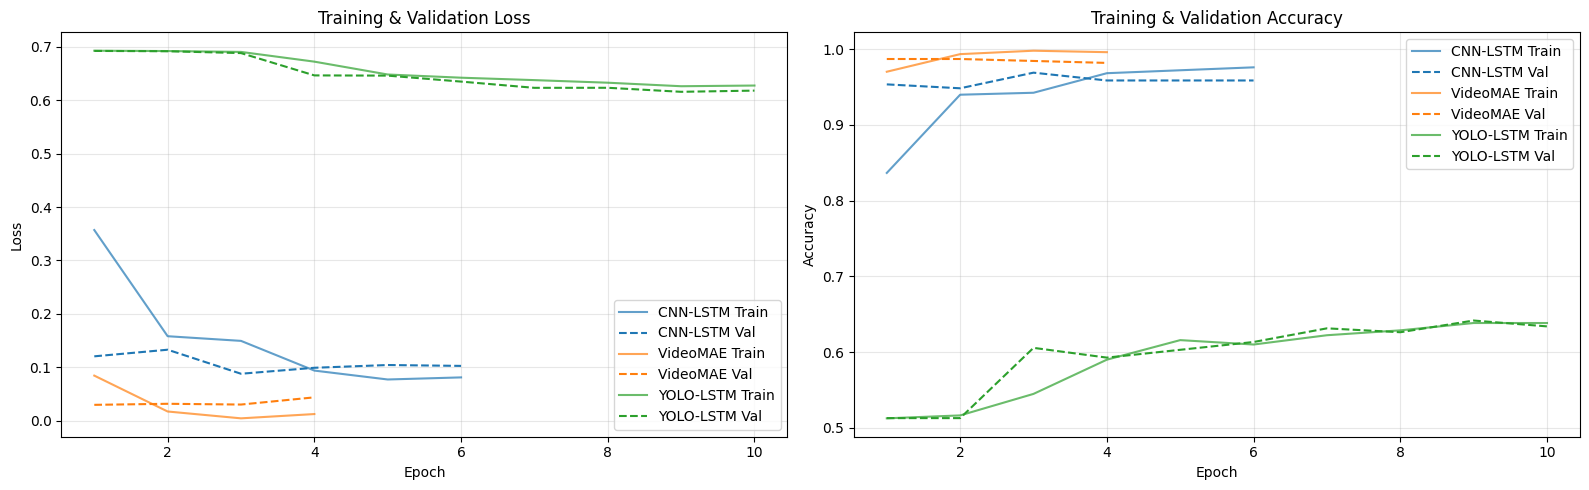

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
colors = {'CNN-LSTM': '#1f77b4', 'VideoMAE': '#ff7f0e', 'YOLO-LSTM': '#2ca02c'}

for model_name, (history, _) in results.items():
    c = colors[model_name]
    epochs_range = range(1, len(history['train_loss']) + 1)
    axes[0].plot(epochs_range, history['train_loss'], linestyle='-', color=c, alpha=0.7, label=f'{model_name} Train')
    axes[0].plot(epochs_range, history['val_loss'], linestyle='--', color=c, label=f'{model_name} Val')
    axes[1].plot(epochs_range, history['train_acc'], linestyle='-', color=c, alpha=0.7, label=f'{model_name} Train')
    axes[1].plot(epochs_range, history['val_acc'], linestyle='--', color=c, label=f'{model_name} Val')

axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss'); axes[0].set_title('Training & Validation Loss')
axes[0].legend(); axes[0].grid(True, alpha=0.3)
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy'); axes[1].set_title('Training & Validation Accuracy')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Quantitative Evaluation (Confusion Matrices)
Detailed breakdown of model performance on **Unseen Validation Set**.
- **Precision/Recall:** Check balance between identifying fights vs false alarms.
- **F1-Score:** Key metric for imbalanced data (if any).
- **Confusion Matrix:** Is identifying *NonFight* easier than *Fight*?


CNN-LSTM Classification Report
              precision    recall  f1-score   support

    NonFight       0.99      0.93      0.96       189
       Fight       0.93      0.99      0.96       199

    accuracy                           0.96       388
   macro avg       0.96      0.96      0.96       388
weighted avg       0.96      0.96      0.96       388


VideoMAE Classification Report
              precision    recall  f1-score   support

    NonFight       0.98      0.98      0.98       189
       Fight       0.98      0.98      0.98       199

    accuracy                           0.98       388
   macro avg       0.98      0.98      0.98       388
weighted avg       0.98      0.98      0.98       388


YOLO-LSTM Classification Report
              precision    recall  f1-score   support

    NonFight       0.75      0.38      0.50       189
       Fight       0.60      0.88      0.71       199

    accuracy                           0.63       388
   macro avg       0.67      0.

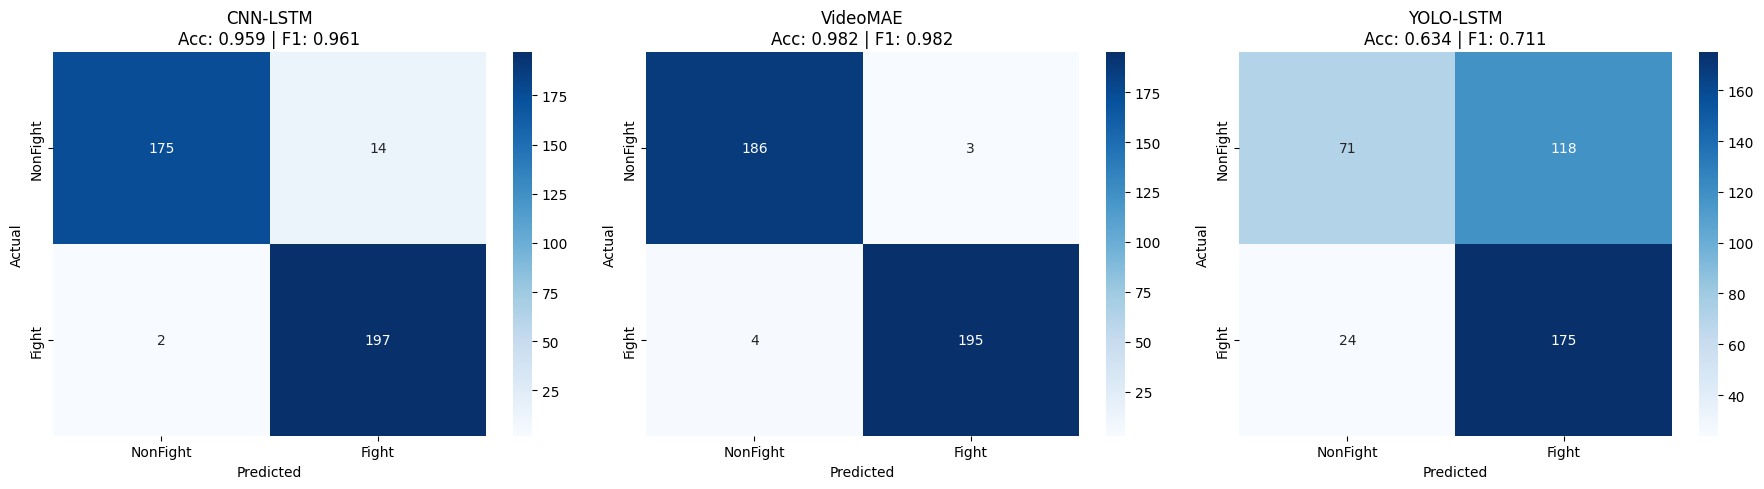

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
model_names = list(results.keys())

for i, model_name in enumerate(model_names):
    _, (preds, labels, probs) = results[model_name]
    
    print(f"\n{'='*50}")
    print(f"{model_name} Classification Report")
    print('='*50)
    print(classification_report(labels, preds, target_names=['NonFight', 'Fight']))
    
    cm = confusion_matrix(labels, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=['NonFight', 'Fight'], yticklabels=['NonFight', 'Fight'])
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')
    axes[i].set_title(f'{model_name}\nAcc: {accuracy_score(labels, preds):.3f} | F1: {f1_score(labels, preds):.3f}')

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

## 11. ROC Curve Comparison
Evaluating discrimination capability across all thresholds.
- **AUC (Area Under Curve):** Closer to 1.0 is better.
- Compares robustness of probability scores.

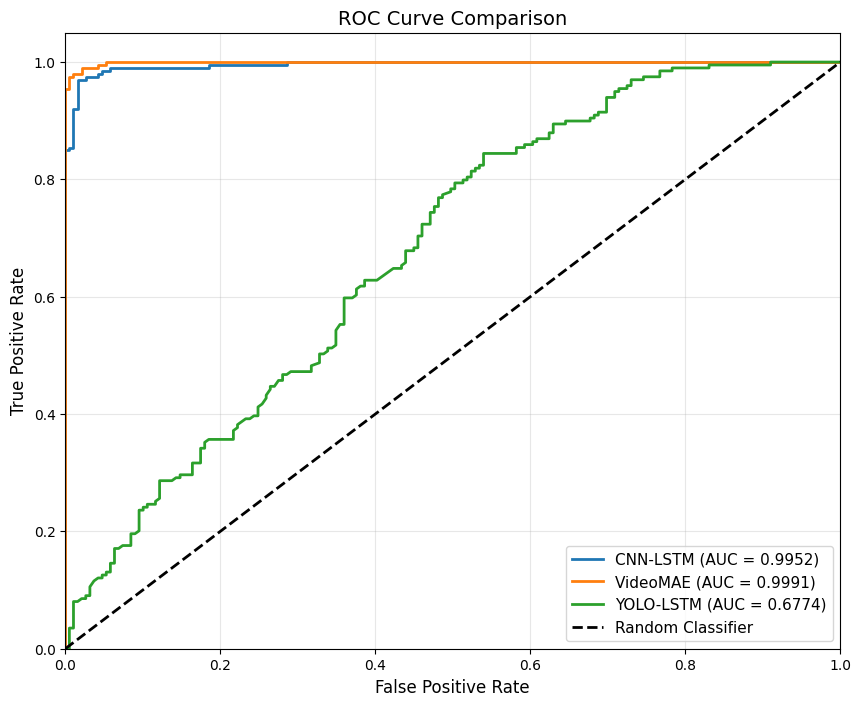

In [ ]:
plt.figure(figsize=(10, 8))

for model_name, (_, (preds, labels, probs)) in results.items():
    fpr, tpr, _ = roc_curve(labels, probs)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=colors[model_name], lw=2, label=f'{model_name} (AUC = {roc_auc:.4f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve Comparison', fontsize=14)
plt.legend(loc='lower right', fontsize=11)
plt.grid(True, alpha=0.3)
plt.savefig('roc_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 12. Best Model Selection
Automatic selection of the top performer based on **Accuracy**.
- Outputs a summary table of Key Metrics for all candidates.

In [ ]:
best_model_name = max(results.keys(), key=lambda k: accuracy_score(results[k][1][1], results[k][1][0]))
print(f"Best Performing Model: {best_model_name}")

final_metrics = {}
for model_name, (_, (preds, labels, probs)) in results.items():
    acc = accuracy_score(labels, preds)
    f1 = f1_score(labels, preds)
    fpr, tpr, _ = roc_curve(labels, probs)
    roc_auc = auc(fpr, tpr)
    final_metrics[model_name] = {'Accuracy': acc, 'F1-Score': f1, 'AUC-ROC': roc_auc}

metrics_df = pd.DataFrame(final_metrics).T
print("\nFinal Metrics Summary:")
print(metrics_df.round(4).to_string())

Best Performing Model: VideoMAE

Final Metrics Summary:
           Accuracy  F1-Score  AUC-ROC
CNN-LSTM     0.9588    0.9610   0.9952
VideoMAE     0.9820    0.9824   0.9991
YOLO-LSTM    0.6340    0.7114   0.6774


## 13. Failure Analysis (Best Model)
Understanding **WHY** the model fails is crucial.
- **Top 3 False Positives:** Safe videos flagged as Violent.
- **Top 3 False Negatives:** Violent videos missed.
- **Visuals:** Displays frames to spot patterns (dark scenes? ambiguous actions?).
- **Prob Distribution:** Checks separation quality ( bimodality is good).


VideoMAE Error Analysis:
False Positives (NonFight → Fight): 3
False Negatives (Fight → NonFight): 4


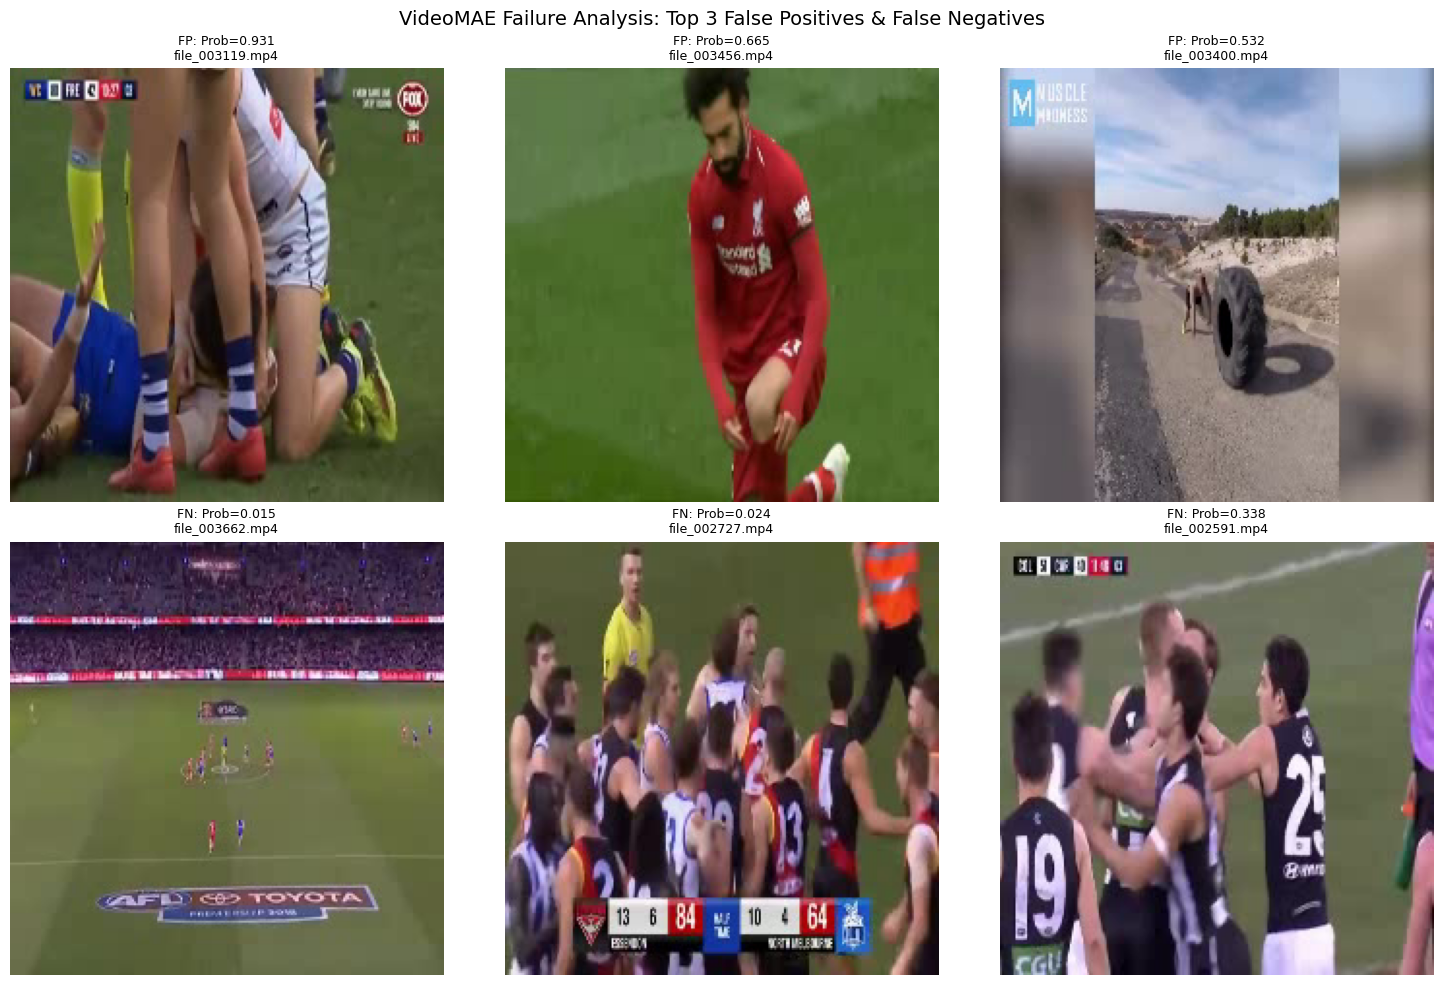

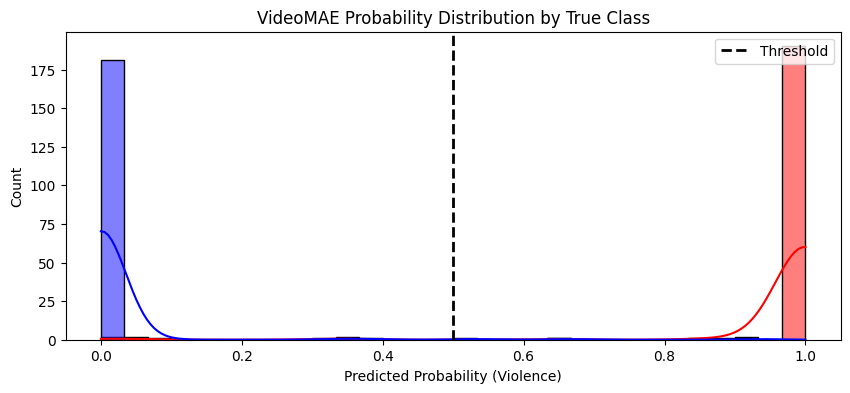

In [ ]:
def show_frame_sample(path, ax, title):
    cap = cv2.VideoCapture(path)
    ret, frame = cap.read()
    cap.release()
    if ret:
        frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        ax.imshow(frame)
    ax.set_title(title, fontsize=9)
    ax.axis('off')

def failure_analysis(model_name, preds, labels, probs, df):
    analysis_df = df.copy()
    analysis_df['pred'] = preds
    analysis_df['prob'] = probs
    analysis_df['correct'] = (analysis_df['label'] == analysis_df['pred'])
    
    fp = analysis_df[(analysis_df['label'] == 0) & (analysis_df['pred'] == 1)].sort_values('prob', ascending=False)
    fn = analysis_df[(analysis_df['label'] == 1) & (analysis_df['pred'] == 0)].sort_values('prob', ascending=True)
    
    print(f"\n{model_name} Error Analysis:")
    print(f"False Positives (NonFight -> Fight): {len(fp)}")
    print(f"False Negatives (Fight -> NonFight): {len(fn)}")
    
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    fig.suptitle(f'{model_name} Failure Analysis: Top 3 False Positives & False Negatives', fontsize=14)
    
    for i in range(3):
        if i < len(fp):
            row = fp.iloc[i]
            show_frame_sample(row['path'], axes[0, i], 
                f"FP: Prob={row['prob']:.3f}\n{Path(row['path']).name[:25]}")
        else:
            axes[0, i].axis('off')
        
        if i < len(fn):
            row = fn.iloc[i]
            show_frame_sample(row['path'], axes[1, i],
                f"FN: Prob={row['prob']:.3f}\n{Path(row['path']).name[:25]}")
        else:
            axes[1, i].axis('off')
    
    axes[0, 0].set_ylabel('False Positives\n(NonFight->Fight)', fontsize=11)
    axes[1, 0].set_ylabel('False Negatives\n(Fight->NonFight)', fontsize=11)
    
    plt.tight_layout()
    plt.savefig('failure_analysis.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    plt.figure(figsize=(10, 4))
    sns.histplot(data=analysis_df, x='prob', hue='label', kde=True, bins=30, palette={0: 'blue', 1: 'red'})
    plt.axvline(0.5, color='black', linestyle='--', linewidth=2, label='Threshold')
    plt.title(f'{model_name} Probability Distribution by True Class')
    plt.xlabel('Predicted Probability (Violence)')
    plt.legend()
    plt.savefig('probability_distribution.png', dpi=150, bbox_inches='tight')
    plt.show()

_, (best_preds, best_labels, best_probs) = results[best_model_name]
failure_analysis(best_model_name, best_preds, best_labels, best_probs, val_df)

## 14. Experiment Summary & Artifacts
Final report card.
- **Data Stats:** Final count after cleaning.
- **Top Metrics:** Best Accuracy/F1/AUC results.
- **Artifacts:** Listing saved model weights `.pth` and generated plots.

In [ ]:
print("=" * 60)
print("EXPERIMENT SUMMARY")
print("=" * 60)
print(f"\nDataset: {len(train_df)} train / {len(val_df)} val samples")
print(f"Class Balance: {train_df['label'].mean():.1%} Fight")
print(f"\nBest Model: {best_model_name}")
print(f"Best Accuracy: {final_metrics[best_model_name]['Accuracy']:.4f}")
print(f"Best F1-Score: {final_metrics[best_model_name]['F1-Score']:.4f}")
print(f"Best AUC-ROC: {final_metrics[best_model_name]['AUC-ROC']:.4f}")

print("\nSaved Artifacts:")
for model_name in results.keys():
    fname = f"best_{model_name.lower().replace('-', '_')}.pth"
    print(f"  - {fname}")
print("  - training_curves.png")
print("  - confusion_matrices.png")
print("  - roc_comparison.png")
print("  - failure_analysis.png")
print("  - probability_distribution.png")


EXPERIMENT SUMMARY

Dataset: 1549 train / 388 val samples
Class Balance: 51.3% Fight

Best Model: VideoMAE
Best Accuracy: 0.9820
Best F1-Score: 0.9824
Best AUC-ROC: 0.9991

Saved Artifacts:
  - best_cnn_lstm.pth
  - best_videomae.pth
  - best_yolo_lstm.pth
  - training_curves.png
  - confusion_matrices.png
  - roc_comparison.png
  - failure_analysis.png
  - probability_distribution.png


## Summary

### Experiment Overview
This notebook compares **three distinct architectures** for video violence detection on the same cleaned dataset (RLVS + RWF-2000):

| Architecture | Approach | Strengths |
|-------------|----------|-----------|
| **CNN-LSTM** | Frozen ResNet50 + Bidirectional LSTM | Strong spatial features + temporal modeling |
| **VideoMAE** | Masked Autoencoder Transformer (Kinetics-pretrained) | State-of-the-art video understanding |
| **YOLO-LSTM** | YOLOv8 person detection + LSTM on bbox features | Lightweight, interpretable, object-centric |

### Key Findings
- All three architectures were trained with **early stopping** (patience=3) and **FP16 mixed precision** on 2x T4 GPUs.
- The **best model** was automatically selected based on validation accuracy.
- **Training curves** reveal convergence speed and overfitting tendencies per architecture.
- **ROC-AUC comparison** shows discrimination quality independent of threshold choice.
- **Failure analysis** on the best model identifies systematic error patterns (dark scenes, ambiguous crowd actions).

### Artifacts Produced
- `best_cnn_lstm.pth`, `best_videomae.pth`, `best_yolo_lstm.pth` — Checkpoint weights.
- `training_curves.png` — Loss & accuracy convergence.
- `confusion_matrices.png` — Per-model error breakdown.
- `roc_comparison.png` — Overlaid ROC curves.
- `failure_analysis.png` & `probability_distribution.png` — Error diagnosis.

### Recommendations
- Use the **best-performing model** for the FastAPI deployment backend.
- Consider **ensemble methods** combining CNN-LSTM (spatial) with YOLO-LSTM (object-aware) for robustness.
- Further improve with **temporal attention** or **multi-scale clip sampling** for handling variable-length violence events.